I got the dataset from kaggle [here](https://www.kaggle.com/datasets/thedevastator/tinysol-isolated-musical-notes-from-14-musical-i).

I decided to reduce the dimensionality of the model for our use case

https://reference.wolfram.com/language/ref/netencoder/Audio.html

Using the tutorial above, I settled on using the AudioMFCC encoder, which has a corresponding function in a Python library

https://docs.pytorch.org/audio/master/generated/torchaudio.transforms.MFCC.html



I couldn't get torchaudio working, so intead I am using a different library
[text](https://python-speech-features.readthedocs.io/en/latest/#)

In [ ]:
def get_data():
    

In [70]:
from python_speech_features import mfcc
from python_speech_features import logfbank
import scipy.io.wavfile as wav

nfft = 4096

(rate,sig) = wav.read("Brass/Bass_Tuba/ordinario/BTb-ord-A1-ff-N-T19d.wav")
(rate,sig) = wav.read("Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav")

mfcc_feat = mfcc(sig,rate, nfft=nfft, winlen=50e-3)
print(mfcc_feat[mfcc_feat.shape[0]//2,:])

nfft = 4096
(rate,sig) = wav.read("Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav")
mfcc_feat = mfcc(sig,rate, nfft=nfft, winlen=50e-3 )
# fbank_feat = logfbank(sig,rate, nfft=nfft)

print(mfcc_feat[mfcc_feat.shape[0]//2,:])

[ 1.05232418e+01  1.50886601e+01  3.85805988e+01  1.79492429e+01
  8.52495982e+00 -1.18145777e+01 -2.21171281e+01 -2.53219275e+01
 -1.68481408e+01 -1.38413999e+01 -1.36445878e-02  1.22098067e+01
 -3.67459202e-01]
[ 1.05232418e+01  1.50886601e+01  3.85805988e+01  1.79492429e+01
  8.52495982e+00 -1.18145777e+01 -2.21171281e+01 -2.53219275e+01
 -1.68481408e+01 -1.38413999e+01 -1.36445878e-02  1.22098067e+01
 -3.67459202e-01]


In [71]:
# import matplotlib.pyplot as plt
# import librosa.display

# fig = plt.subplots(figsize=(10, 50))

# librosa.display.specshow(mfcc_feat.T)
# plt.imshow(mfcc_feat.T)

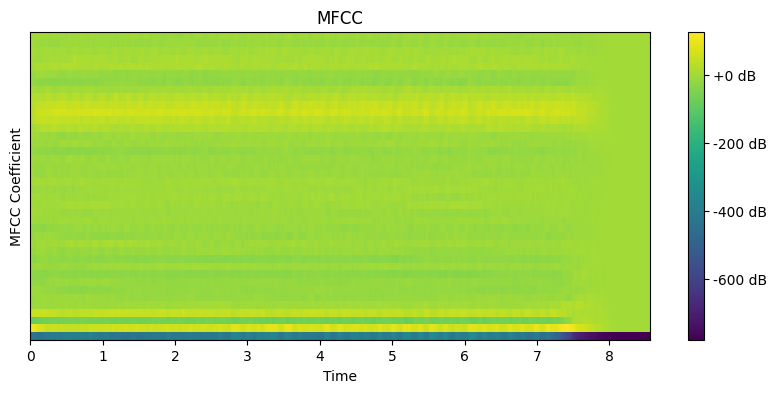

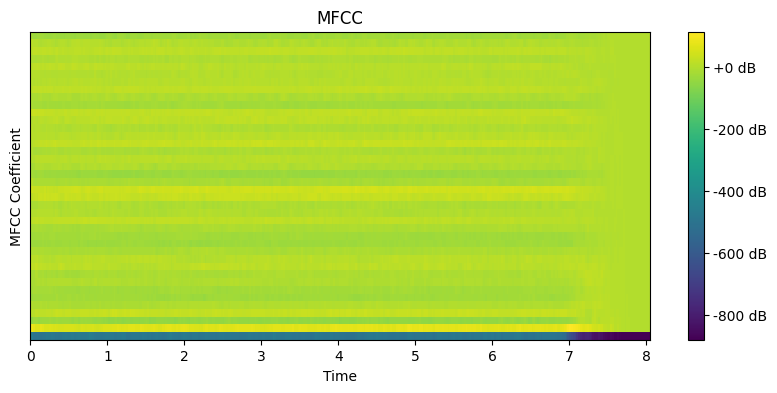

In [85]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

def plot_mfcc(audio_path):
    # Load the audio file
    y, sr = librosa.load(audio_path)

    # Extract MFCC features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40, n_fft=1800)

    # Plot MFCCs
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfccs, x_axis='time', cmap='viridis')
    plt.colorbar(format='%+2.0f dB')
    plt.title('MFCC')
    plt.xlabel('Time')
    plt.ylabel('MFCC Coefficient')
    plt.show()

# Example usage
# audio_file_path1 = "Brass/Bass_Tuba/ordinario/BTb-ord-A1-ff-N-T19d.wav"
# audio_file_path2 = "Brass/Bass_Tuba/ordinario/BTb-ord-D#3-mf-N-T25u.wav"
# audio_file_path1 = "Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav"
# audio_file_path2 = "Brass/Horn/ordinario/Hn-ord-D#2-pp-N-R100u.wav"
audio_file_path1 = "Strings/Viola/ordinario/Va-ord-A#3-ff-3c-N.wav"
audio_file_path2 = "Strings/Viola/ordinario/Va-ord-G5-ff-3c-N.wav"
plot_mfcc(audio_file_path1)
plot_mfcc(audio_file_path2)

In [73]:
rate

len(sig) / rate

6.127641723356009

In [74]:
mfcc_feat.shape
fbank_feat.shape

612*0.01

6.12

In [75]:
import scipy

scipy.io.wavfile.read("Brass/Horn/ordinario/Hn-ord-A1-mf-N-N.wav")

(44100, array([-1, -3, -4, ..., -1,  0,  0], shape=(270229,), dtype=int16))

I found this [tutorial](https://www.geeksforgeeks.org/machine-learning/classification-using-sklearn-multi-layer-perceptron/) helpful


In [76]:
from sklearn.neural_network import MLPClassifier

clf = MLPClassifier(hidden_layer_sizes=(5,5, 4), activation='relu', random_state=42)

clf.fit(X, y)

NameError: name 'X' is not defined